# Instructions
- Some parts of the code are already done for you
- You need to execute all the cells
- You need to add the code where ever you see `"#### Add your code here ####"`
- Marks are mentioned along with the cells

# Face recognition
Task is to recognize a faces

### Dataset
**Aligned Face Dataset from Pinterest**

This dataset contains 10.770 images for 100 people. All images are taken from 'Pinterest' and      aligned using dlib library.

In [0]:
%tensorflow_version 2.x

In [0]:
import tensorflow
tensorflow.__version__

'2.0.0'

#### Mount Google drive if you are using google colab
- We recommend using Google Colab as you can face memory issues and longer runtimes while running on local

In [0]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


#### Change current working directory to project folder (1 mark)

In [0]:
#### Add your code here ####
import os

#create a data-directory
data_dir = '/content/data'
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

#change working directory
os.chdir(data_dir)
!pwd

/content/data


### Extract the zip file (2 marks)
- Extract Aligned Face Dataset from Pinterest.zip

In [0]:
#### Add your code here ####
!cp "/content/drive/My Drive/GreatLearning/Lab/AdvancedCompVision_Project2/Pinterest.zip" .
!unzip Pinterest.zip

Archive:  Pinterest.zip
  inflating: PINS/pins_Aaron Paul/Aaron Paul0_262.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul101_247.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul101_248.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul101_249.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul103_217.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul113_228.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul114_271.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul116_240.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul117_213.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul119_219.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul120_290.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul124_221.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul126_291.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul129_259.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul129_260.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul130_215.jpg  
  inflating: PINS/pins_Aaron Paul/Aaron Paul132_23

In [0]:
# check the number of file-images from the zip
!find /content/data/PINS/ -name *.jpg | wc -l

10770


### Function to load images
- Define a function to load the images from the extracted folder and map each image with person id 


In [0]:
import numpy as np
import os

class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)


metadata = load_metadata('./PINS')

In [40]:
metadata.shape

(10770,)

### Define function to load image
- Define a function to load image from the metadata

In [0]:
import cv2
def load_image(path):
    img = cv2.imread(path,1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

#### Load a sample image (2 marks)
- Load one image using the function "load_image"

rand_image_file= ./PINS/pins_jason isaacs/jason isaacs45_2066.jpg


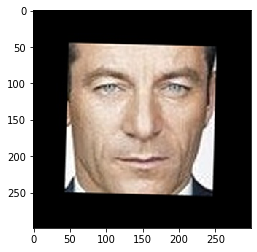

In [46]:
#### Add your code here ####
import random 

rd = random.randrange(1, metadata.shape[0], 10)
rand_image_file  = metadata[rd].image_path()
print ("rand_image_file=", rand_image_file)
img = load_image(rand_image_file)
plt.imshow(img)

### VGG Face model
- Here we are giving you the predefined model for VGG face

In [0]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Load the model (2 marks)
- Load the model defined above
- Then load the given weight file named "vgg_face_weights.h5"

In [0]:
#### Add your code here ####
model = vgg_face()

!cp "/content/drive/My Drive/GreatLearning/Lab/AdvancedCompVision_Project2/vgg_face_weights.h5" .
model.load_weights("./vgg_face_weights.h5")

### Get vgg_face_descriptor

In [0]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

### Generate embeddings for each image in the dataset
- Given below is an example to load the first image in the metadata and get its embedding vector from the pre-trained model. 

In [0]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
(2622,)


### Generate embeddings for all images (5 marks)
- Write code to iterate through metadata and create embeddings for each image using `vgg_face_descriptor.predict()` and store in a list with name `embeddings`

- If there is any error in reading any image in the dataset, fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [0]:
#### Add your code here ####
def get_embedding_img(img_path, vgg_model):
  img = load_image(img_path)

  # Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
  img = (img / 255.).astype(np.float32)

  img = cv2.resize(img, dsize = (224,224))

  # Obtain embedding vector for an image
  # Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 
  embedding_vector = vgg_model.predict(np.expand_dims(img, axis=0))[0]
  return embedding_vector

In [17]:
from tqdm import tqdm

embeddings = []

with tqdm(total=len(metadata)) as pbar:
  for img_item in metadata:
    img_path = img_item.image_path()
    #print (img_path)
    embed_item = get_embedding_img(img_path, vgg_face_descriptor)
    embeddings.append(embed_item)
    pbar.update(1)

100%|██████████| 10770/10770 [23:20<00:00,  7.63it/s]


### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [0]:
def distance(emb1, emb2):
    return np.sum(np.square(emb1 - emb2))

#### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

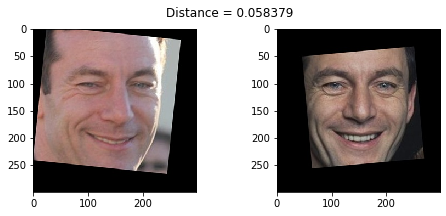

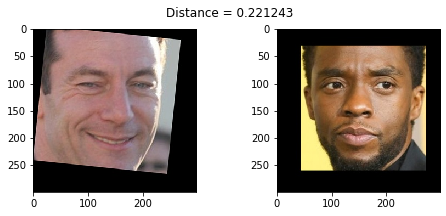

In [20]:
import matplotlib.pyplot as plt

def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

show_pair(2, 3)
show_pair(2, 180)

### Create train and test sets (5 marks)
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [21]:
embeddings = np.array(embeddings)
len(embeddings)

10770

In [22]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0
test_idx = np.arange(metadata.shape[0]) % 9 == 0

#### Add your code here ####
X_train = np.array(embeddings)[train_idx]
X_test = np.array(embeddings)[test_idx]
print("X_train_count = %d, X_test_count = %d" % (len(X_train), len(X_test)))

X_train_count = 9573, X_test_count = 1197


In [23]:
targets = np.array([m.name for m in metadata])
y_train_1 = targets[train_idx]
y_test_1 = targets[test_idx]
print("y_train_count = %d, y_test_count = %d" % (len(y_train_1), len(y_test_1)))

y_train_count = 9573, y_test_count = 1197


### Encode the Labels (3 marks)
- Encode the targets
- Use LabelEncoder

In [0]:
from sklearn.preprocessing import LabelEncoder

#### Add your code here ####
out_encoder = LabelEncoder()
out_encoder.fit(y_train_1)
y_train = out_encoder.transform(y_train_1)
y_test = out_encoder.transform(y_test_1)

### Standardize the feature values (3 marks)
- Scale the features using StandardScaler

In [0]:
# Standarize features
from sklearn.preprocessing import StandardScaler

#### Add your code here ####
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Reduce dimensions using PCA (3 marks)
- Reduce feature dimensions using Principal Component Analysis

In [0]:
from sklearn.decomposition import PCA

#### Add your code here ####
pca = PCA()
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [48]:
pca.components_

array([[-0.0237878 ,  0.00902259, -0.00297046, ..., -0.00820292,
         0.02135759,  0.03890238],
       [ 0.02114096, -0.00110704,  0.00888315, ..., -0.02301243,
        -0.0040286 ,  0.01144395],
       [ 0.00282719,  0.00187911, -0.00690163, ...,  0.01110799,
        -0.00109277, -0.01587334],
       ...,
       [ 0.00061732,  0.00023986, -0.00124676, ...,  0.00094203,
         0.00115493,  0.00043109],
       [-0.00010366, -0.0009805 ,  0.00042814, ..., -0.00105923,
         0.00096393,  0.00015001],
       [-0.01704061, -0.0211142 , -0.01861959, ..., -0.01931747,
        -0.01909736, -0.02310129]], dtype=float32)

In [49]:
pca.explained_variance_ratio_

array([1.3596351e-01, 5.3772360e-02, 3.9926726e-02, ..., 1.6834008e-09,
       1.6550576e-09, 9.2932502e-11], dtype=float32)

### Build a Classifier (3 marks)
- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [51]:
#svc_model = SVC(C=0.01, kernel='linear')
svc_model = SVC()
svc_model.fit(X_train_pca, y_train)

# check the accuracy on the training set
print(svc_model.score(X_train_pca, y_train))
print(svc_model.score(X_test_pca, y_test))

0.9974929489188342
0.9707602339181286


### Test results (1 mark)
- Take 10th image from test set and plot the image
- Report to which person(folder name in dataset) the image belongs to

In [52]:
import warnings
from numpy import expand_dims
# Suppress LabelEncoder warning
warnings.filterwarnings('ignore')

example_idx = 10

# Get the 10th image 
example_image = load_image(metadata[test_idx][example_idx].image_path())
metadata[test_idx][example_idx].image_path()

'./PINS/pins_jason isaacs/jason isaacs134_2101.jpg'

In [53]:
#example_embed_test =  expand_dims(X_test[example_idx], axis=0) 
#example_prediction = svc_model.predict(pca.transform(example_embed_test))

example_embed_test =  expand_dims(X_test_pca[example_idx], axis=0)
example_prediction = svc_model.predict(example_embed_test)
example_prediction

array([81])

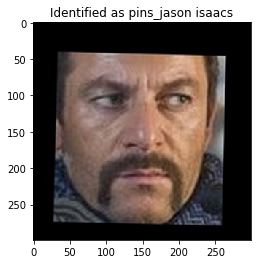

In [54]:
example_identity = out_encoder.inverse_transform(example_prediction)[0]
plt.imshow(example_image)
plt.title(f'Identified as {example_identity}');